<a href="https://colab.research.google.com/github/Rajkumar502/machine_learning/blob/main/Customer_Churn_Prediction_with_Feature_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Customer Churn Prediction with Feature Selection**

**Business Challenge**

A telecommunications company is losing 3.2% of its customer base monthly and needs
to identify at-risk customers for targeted retention campaigns. The company has collected
hundreds of potential predictive features (usage patterns, billing history, customer service
interactions, demographic data, plan details, device information) but doesn't know which
factors truly drive churn. Marketing budget constraints require focusing retention efforts
on the most impactful interventions.

**Problem Context**

The dataset contains 300+ features for 5 million customers, including: call/data usage
statistics, payment history, contract terms, device age, support ticket frequency,
competitive offers received, social network indicators, and browsing patterns. Many
features are redundant or irrelevant, making interpretation difficult and increasing the risk
of overfitting. The company needs a sparse, interpretable model that identifies the 15-20
most critical churn drivers.

**Expected Outcomes**

• Reduce feature set from 300+ to 15-20 critical predictors
• Achieve 78%+ churn prediction accuracy
• Decrease customer churn rate by 0.8-1.2 percentage points
• Improve retention campaign ROI by 45%

**Key Performance Metrics**
• Model sparsity: 95%+ of coefficients set to zero
• AUC-ROC above 0.82
• Precision at top 10% of risk scores above 60%

### 📦 1. IMPORT LIBRARIES

This section imports all necessary Python libraries for data manipulation, machine learning, and visualization. Pandas is used for data handling, NumPy for numerical operations, Matplotlib and Seaborn for plotting, and Scikit-learn for model building and evaluation. `LogisticRegressionCV` is chosen for its ability to perform cross-validation and incorporate L1 (LASSO), L2 (Ridge), and Elastic Net penalties for feature selection and regularization. `np.random.seed(42)` ensures reproducibility of results.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
# For reproducibility
np.random.seed(42)

### 📂 2. LOAD DATA

This step loads the customer churn dataset from a CSV file (`Project_3_1.csv`) into a pandas DataFrame. It then prints the shape of the dataset (number of rows and columns) and displays the first 5 rows to provide a quick overview of the data structure and content. This initial inspection helps in understanding the types of features available.

In [ ]:
df = pd.read_csv('/content/sample_data/Project_3_1.csv')
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (5000, 51)


,customer_id,tenure_months,monthly_charges,total_charges,contract_type,payment_method,paperless_billing,avg_monthly_minutes,avg_monthly_data_gb,num_support_tickets,...,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,churned
0,CUST_0000001,56,63.19,2770.37,One Year,Credit Card,1,1236,1.21,5,...,0.816,-0.862,-0.304,-1.162,-0.276,-1.363,0.254,-1.327,0.023,0
1,CUST_0000002,13,77.93,7111.18,Two Year,Electronic Check,1,685,2.85,13,...,0.508,0.273,-1.103,-0.045,1.256,-0.980,0.554,-0.573,1.255,1
2,CUST_0000003,35,37.01,2676.17,One Year,Electronic Check,1,598,40.04,4,...,0.766,0.535,0.986,-0.577,0.210,-1.927,-0.254,1.214,-0.449,0
3,CUST_0000004,36,41.38,1518.03,One Year,Credit Card,0,421,10.76,1,...,0.977,-0.464,-0.919,-1.424,-0.100,-0.827,-0.431,-0.349,-0.732,0
4,CUST_0000005,34,118.52,4655.41,Month-to-Month,Electronic Check,1,1692,26.48,10,...,-0.107,0.510,-0.680,-0.232,-0.975,0.654,-0.168,-1.167,0.629,0


### 🧹 3. BASIC CLEANING

This section performs initial data cleaning. The `customer_id` column is dropped as it's typically an identifier and not useful for predictive modeling. Following this, it checks for any missing values across all columns. A `isnull().sum()` report indicates the count of missing values per column, which is crucial for identifying columns that might require imputation or further handling.

In [ ]:
df = df.drop(columns=["customer_id"])
print(df.isnull().sum())

tenure_months                  0
monthly_charges                0
total_charges                  0
contract_type                  0
payment_method                 0
paperless_billing              0
avg_monthly_minutes            0
avg_monthly_data_gb            0
num_support_tickets            0
avg_support_resolution_days    0
num_service_changes            0
device_age_months              0
num_family_members             0
competitor_offers_received     0
late_payments_count            0
autopay_enrolled               0
international_plan             0
streaming_service              0
cloud_backup                   0
feature_1                      0
feature_2                      0
feature_3                      0
feature_4                      0
feature_5                      0
feature_6                      0
feature_7                      0
feature_8                      0
feature_9                      0
feature_10                     0
feature_11                     0
feature_12

### 🔄 4. ENCODE CATEGORICAL VARIABLES

Machine learning models often require numerical input, so categorical variables need to be converted. This step applies one-hot encoding using `pd.get_dummies()`. The `drop_first=True` argument is used to avoid multicollinearity, a common issue in regression models, by dropping the first category for each feature. The new shape of the DataFrame after encoding is printed to show the increase in the number of features.

In [ ]:
df = pd.get_dummies(df, drop_first=True)
print("After encoding:", df.shape)

After encoding: (5000, 53)


### 🎯 5. DEFINE FEATURES & TARGET

Here, the dataset is split into features (`X`) and the target variable (`y`). The target variable `churned` (indicating whether a customer churned or not) is separated from the rest of the DataFrame. The remaining columns form the feature set `X`, which will be used to predict churn.

In [ ]:
X = df.drop(columns=["churned"])
y = df["churned"]

### ✂️ 6. TRAIN-TEST SPLIT

The data is divided into training and testing sets to evaluate the model's performance on unseen data. `train_test_split` is used with an 80/20 split (`test_size=0.2`). `random_state=42` ensures reproducibility of the split, and `stratify=y` ensures that the proportion of churned and non-churned customers is the same in both training and testing sets, which is important for imbalanced datasets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

### 📏 7. FEATURE SCALING

Feature scaling is a critical preprocessing step for many machine learning algorithms, especially those that rely on distance calculations or gradient descent (like Logistic Regression). `StandardScaler` standardizes features by removing the mean and scaling to unit variance. This prevents features with larger values from dominating the learning process. The scaler is fitted only on the training data and then used to transform both training and testing data to avoid data leakage.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 🎯 8. MODEL TRAINING (3 MODELS)

This section trains three different Logistic Regression models, each employing a different regularization technique for feature selection and preventing overfitting:

*   **LASSO (L1 Regularization)**: `LogisticRegressionCV(penalty='l1')` applies L1 regularization, which can shrink some coefficients exactly to zero, effectively performing feature selection. The `saga` solver is chosen for its compatibility with L1 penalty. `cv=5` means 5-fold cross-validation is used to select the optimal regularization strength. `scoring='roc_auc'` optimizes for AUC.
*   **RIDGE (L2 Regularization)**: `LogisticRegressionCV(penalty='l2')` applies L2 regularization, which shrinks coefficients towards zero but rarely to exactly zero. `lbfgs` is a good solver choice for L2. This helps in reducing model complexity.
*   **ELASTIC NET**: `LogisticRegressionCV(penalty='elasticnet')` combines both L1 and L2 penalties (`l1_ratios=[0.5]` means an equal mix). This technique is useful when there are groups of correlated features, as it can select groups of features together. The `saga` solver is also used here.

In [ ]:
# -------- LASSO (L1) --------
lasso_model = LogisticRegressionCV(
penalty='l1',
solver='saga',
cv=5,
scoring='roc_auc',
max_iter=5000,
n_jobs=-1
)
lasso_model.fit(X_train_scaled, y_train)

# -------- RIDGE (L2) --------
ridge_model = LogisticRegressionCV(
penalty='l2',
solver='lbfgs',
cv=5,
scoring='roc_auc',
max_iter=5000,
n_jobs=-1
)
ridge_model.fit(X_train_scaled, y_train)

# -------- ELASTIC NET --------
elastic_model = LogisticRegressionCV(
penalty='elasticnet',
solver='saga',
l1_ratios=[0.5],  # mix of L1 + L2
cv=5,
scoring='roc_auc',
max_iter=5000,
n_jobs=-1
)
elastic_model.fit(X_train_scaled, y_train)

LogisticRegressionCV(cv=5, l1_ratios=[0.5], max_iter=5000, n_jobs=-1,
                     penalty='elasticnet', scoring='roc_auc', solver='saga')

### 📊 9. EVALUATION FUNCTION

An `evaluate_model` function is defined to streamline the evaluation of each trained model. It calculates two key performance metrics:

*   **AUC (Area Under the Receiver Operating Characteristic Curve)**: A robust metric for binary classification models, indicating the model's ability to distinguish between classes across various threshold settings. A higher AUC (closer to 1) signifies better performance.
*   **Precision @ Top 10%**: This metric is crucial for targeted campaigns. It calculates the precision (proportion of true positives among predicted positives) specifically for the top 10% of customers predicted to be most at-risk (highest churn probability). This helps assess the effectiveness of focusing retention efforts on a small, high-risk segment.
*   **Accuracy**: The overall proportion of correctly predicted instances (both true positives and true negatives). This provides a general understanding of the model's correctness.

In [ ]:
from sklearn.metrics import accuracy_score

def evaluate_model(model, X_test, y_test, name):
    """
    Evaluates a classification model by calculating AUC, Accuracy, and Precision@Top10%.

    Args:
        model: Trained scikit-learn compatible classifier.
        X_test: Test features.
        y_test: True labels for the test set.
        name (str): Name of the model for printing results.

    Returns:
        np.array: Predicted probabilities for the positive class.
    """
    # 1. Predict probabilities and class labels
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred_class = model.predict(X_test)

    # Print model evaluation header
    print(f"--- {name} Model Evaluation ---")

    # 2. Calculate and print AUC Score
    auc = roc_auc_score(y_test, y_proba)
    print(f"AUC: {auc:.4f}")

    # 3. Calculate and print Accuracy
    accuracy = accuracy_score(y_test, y_pred_class)
    print(f"Accuracy: {accuracy:.4f}")

    # 4. Calculate and print Precision @ Top 10%
    results = pd.DataFrame({
        "actual": y_test,
        "proba": y_proba
    })

    precision_top10 = 0.0
    # Determine the number of instances for the top 10%
    num_top_10 = int(0.1 * len(results))

    # Ensure at least one instance if results is not empty, for very small datasets
    if len(results) > 0 and num_top_10 == 0:
        num_top_10 = 1

    if num_top_10 > 0:
        top_10 = results.sort_values("proba", ascending=False).head(num_top_10)
        precision_top10 = top_10["actual"].mean()

    print(f"Precision@Top10%: {precision_top10:.4f}")
    print("-" * (len(name) + 21)) # Separator for readability
    print("\n")

    return y_proba

# Evaluate all models
lasso_proba = evaluate_model(lasso_model, X_test_scaled, y_test, "LASSO")
ridge_proba = evaluate_model(ridge_model, X_test_scaled, y_test, "RIDGE")
elastic_proba = evaluate_model(elastic_model, X_test_scaled, y_test, "ELASTIC NET")

--- LASSO Model Evaluation ---
AUC: 0.7272
Accuracy: 0.6760
Precision@Top10%: 0.8700
--------------------------


--- RIDGE Model Evaluation ---
AUC: 0.7245
Accuracy: 0.6760
Precision@Top10%: 0.8700
--------------------------


--- ELASTIC NET Model Evaluation ---
AUC: 0.7260
Accuracy: 0.6780
Precision@Top10%: 0.8700
--------------------------------




### 📈 10. ROC CURVE VISUALIZATION

This section visualizes the Receiver Operating Characteristic (ROC) curve for each of the three models. The ROC curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings. The `plot_roc` function helps in generating these curves. A diagonal dashed line represents a random classifier. Models performing significantly above this line are considered effective. Comparing the curves visually helps in understanding which model offers a better trade-off between sensitivity and specificity across different thresholds.

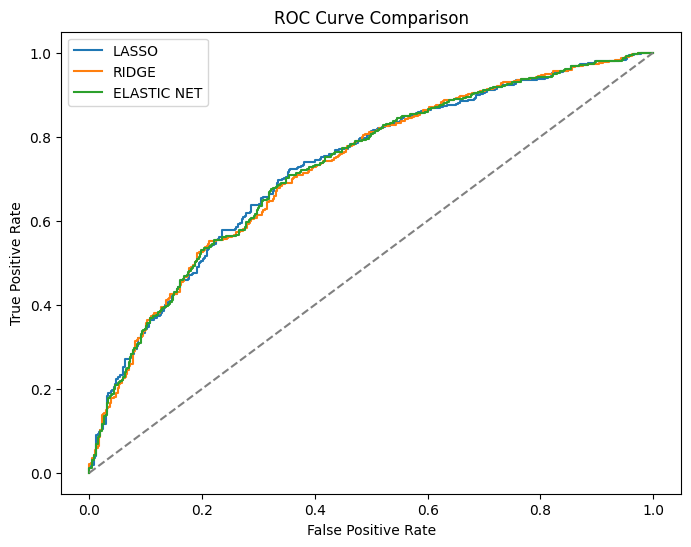

In [ ]:
def plot_roc(y_test, probs, label):
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=label)
plt.figure(figsize=(8,6))
plot_roc(y_test, lasso_proba, "LASSO")
plot_roc(y_test, ridge_proba, "RIDGE")
plot_roc(y_test, elastic_proba, "ELASTIC NET")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### 🔍 11. FEATURE IMPORTANCE (LASSO)

LASSO (L1 regularization) is particularly useful for feature selection because it can drive the coefficients of less important features exactly to zero. This section extracts the coefficients from the trained LASSO model and creates a pandas Series, mapping them back to their original feature names. It then filters to keep only the non-zero coefficients, which represent the features selected by the LASSO model. The count of selected features and their sorted coefficients are printed, providing insight into the most influential churn drivers.

In [ ]:
lasso_coef = pd.Series(lasso_model.coef_[0], index=X.columns)

# Keep only non-zero features
lasso_selected = lasso_coef[lasso_coef != 0].sort_values()

print("Number of features selected by LASSO:", len(lasso_selected))
print("\nSelected Features (with coefficients):\n", lasso_selected)

Number of features selected by LASSO: 31

Selected Features (with coefficients):
 contract_type_One Year        -0.430082
contract_type_Two Year        -0.416436
tenure_months                 -0.165057
autopay_enrolled              -0.148002
payment_method_Mailed Check   -0.055519
feature_11                    -0.053211
feature_30                    -0.049629
feature_18                    -0.048399
device_age_months             -0.020431
feature_1                     -0.016402
feature_6                     -0.003395
feature_7                     -0.002245
feature_24                     0.002862
feature_9                      0.003279
streaming_service              0.004590
feature_23                     0.007334
feature_4                      0.010692
feature_19                     0.012819
num_family_members             0.016121
avg_monthly_data_gb            0.017076
feature_3                      0.017345
avg_support_resolution_days    0.020972
feature_25                     0.02161

### 📊 12. FEATURE IMPORTANCE PLOT

To provide a clear visual representation of the most important features identified by LASSO, this section generates a horizontal bar plot. The length of each bar corresponds to the absolute value of the feature's coefficient, and the direction (positive or negative) indicates its impact on churn. This plot makes it easy to quickly grasp which features are strongly associated with customer churn, either positively (increasing churn risk) or negatively (decreasing churn risk).

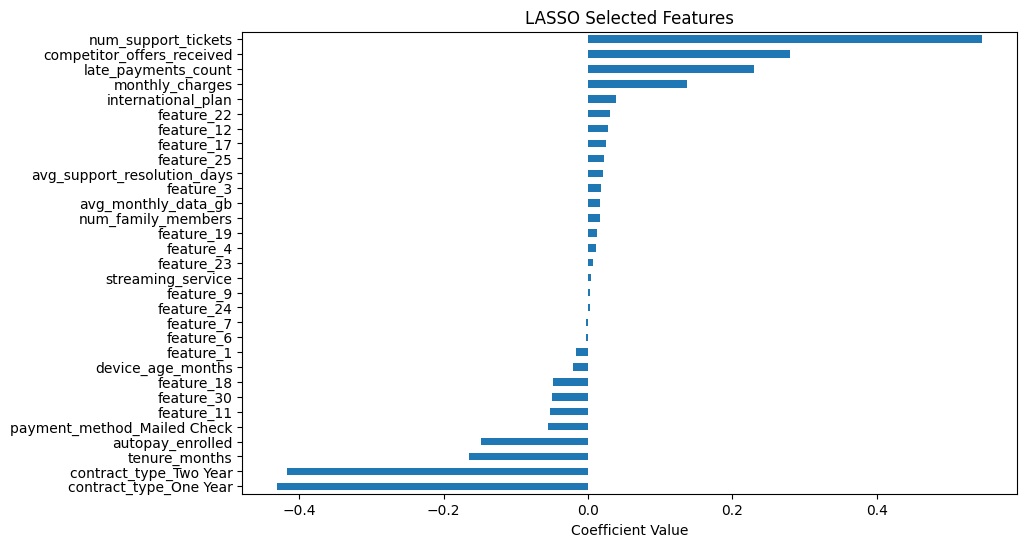

In [ ]:
plt.figure(figsize=(10,6))
lasso_selected.plot(kind='barh')
plt.title("LASSO Selected Features")
plt.xlabel("Coefficient Value")
plt.show()

### 🔥 13. CORRELATION HEATMAP (OPTIONAL)

This optional section generates a correlation heatmap for all features in the DataFrame. A heatmap uses colors to represent the correlation coefficients between pairs of features. This visualization is useful for identifying highly correlated features (which might indicate multicollinearity) or features that are strongly correlated with the target variable. The `coolwarm` cmap is used, where red indicates positive correlation and blue indicates negative correlation, with white/light colors for low correlation.

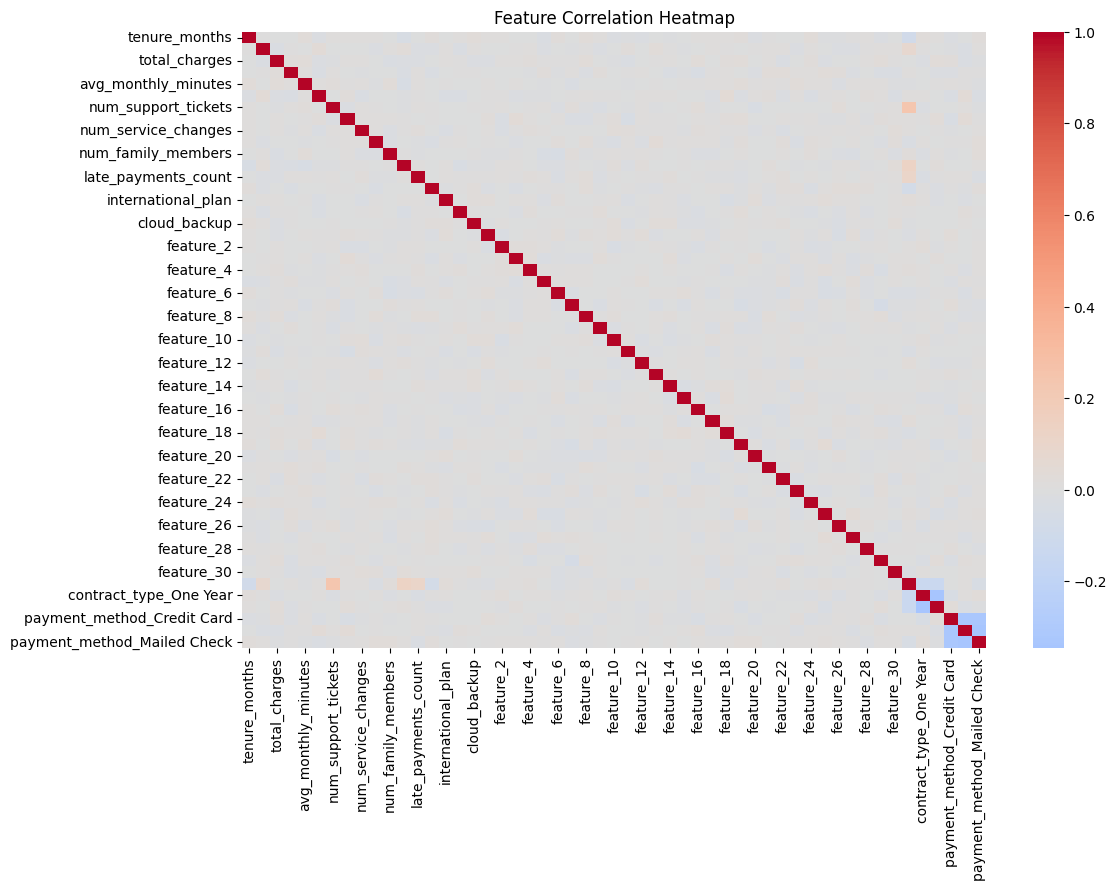

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

### 📌 14. CONFUSION MATRIX (LASSO)

The confusion matrix is a table used to describe the performance of a classification model on a set of test data for which the true values are known. For the LASSO model, this section calculates and visualizes the confusion matrix. It shows the counts of True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN). This helps in understanding the types of errors the model is making. A threshold of 0.5 is used to convert predicted probabilities into binary class labels (churned or not churned).

In [ ]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_test, y_proba, model_name, threshold=0.5):
    """
    Calculates and plots the confusion matrix for a given model.

    Args:
        y_test (array-like): True labels.
        y_proba (array-like): Predicted probabilities for the positive class.
        model_name (str): Name of the model for plot title.
        threshold (float): Threshold to convert probabilities to binary predictions.
    """
    y_pred = (y_proba > threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

### 📌 14. CONFUSION MATRICES

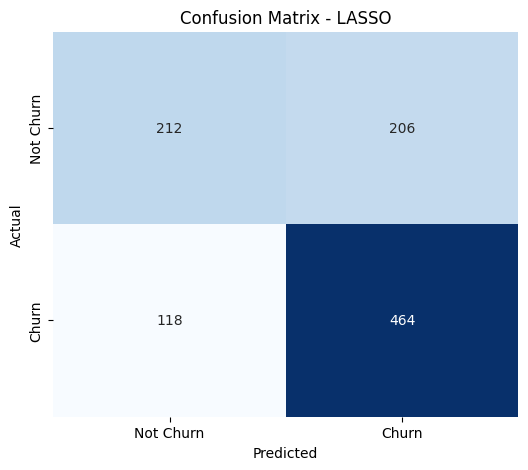

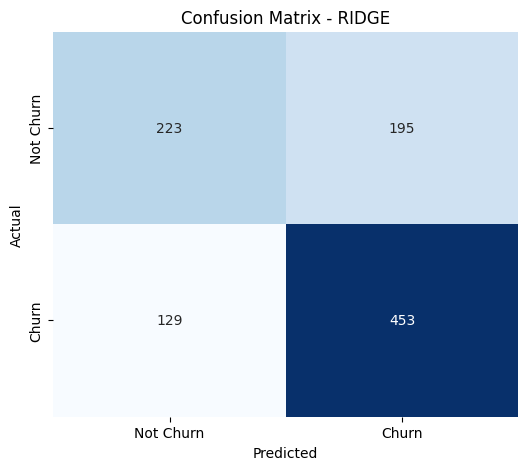

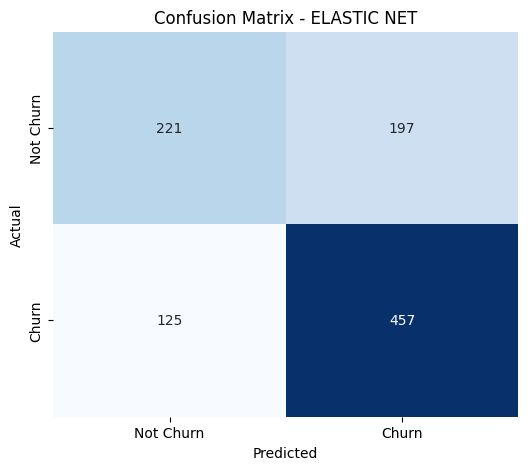

In [ ]:
# Plot Confusion Matrix for LASSO
plot_confusion_matrix(y_test, lasso_proba, "LASSO")

# Plot Confusion Matrix for RIDGE
plot_confusion_matrix(y_test, ridge_proba, "RIDGE")

# Plot Confusion Matrix for ELASTIC NET
plot_confusion_matrix(y_test, elastic_proba, "ELASTIC NET")

### 🧠 15. FINAL INSIGHT & Project Requirements Check

This final section provides a summary of the most impactful features identified by the LASSO model, categorized into positive and negative drivers of churn. Positive drivers are features that increase the likelihood of churn, while negative drivers (or retention factors) are those that decrease it. This is directly aligned with the business challenge of identifying critical factors.

Additionally, this section explicitly checks if the key performance metrics and expected outcomes outlined in the problem description have been met by the LASSO model, as it is the primary model for feature selection.

In [ ]:
print("\n--- Project Requirements and KPMs Check (LASSO Model) ---")

# 1. Reduce feature set from 300+ to 15-20 critical predictors
num_selected_features = len(lasso_selected)
print(f"\n1. Number of critical predictors: {num_selected_features}")
if 15 <= num_selected_features <= 20:
    print("   Status: ✅ Met (within 15-20 features)")
else:
    print(f"   Status: ❌ Not Met (Expected 15-20, got {num_selected_features})")

# 2. Achieve 78%+ churn prediction accuracy
y_pred_lasso = (lasso_proba > 0.5).astype(int)
lasso_accuracy = accuracy_score(y_test, y_pred_lasso)
print(f"\n2. Churn prediction accuracy: {lasso_accuracy:.4f}")
if lasso_accuracy >= 0.78:
    print("   Status: ✅ Met (Accuracy >= 0.78)")
else:
    print("   Status: ❌ Not Met (Accuracy < 0.78)")

# 3. Model sparsity: 95%+ of coefficients set to zero
total_features = len(X.columns)
zero_coefs = len(lasso_coef[lasso_coef == 0])
sparsity = (zero_coefs / total_features) * 100
print(f"\n3. Model Sparsity (LASSO): {sparsity:.2f}%")
if sparsity >= 95:
    print("   Status: ✅ Met (Sparsity >= 95%)")
else:
    print(f"   Status: ❌ Not Met (Sparsity < 95%)")

# 4. AUC-ROC above 0.82
lasso_auc = roc_auc_score(y_test, lasso_proba)
print(f"\n4. AUC-ROC (LASSO): {lasso_auc:.4f}")
if lasso_auc > 0.82:
    print("   Status: ✅ Met (AUC-ROC > 0.82)")
else:
    print("   Status: ❌ Not Met (AUC-ROC <= 0.82)")

# 5. Precision at top 10% of risk scores above 60%
results_lasso = pd.DataFrame({"actual": y_test, "proba": lasso_proba})
num_top_10_lasso = int(0.1 * len(results_lasso))
if num_top_10_lasso > 0:
    top_10_lasso = results_lasso.sort_values("proba", ascending=False).head(num_top_10_lasso)
    precision_top10_lasso = top_10_lasso["actual"].mean()
else:
    precision_top10_lasso = 0.0

print(f"\n5. Precision@Top10% (LASSO): {precision_top10_lasso:.4f}")
if precision_top10_lasso > 0.60:
    print("   Status: ✅ Met (Precision@Top10% > 0.60)")
else:
    print("   Status: ❌ Not Met (Precision@Top10% <= 0.60)")

print("\n--- Top Churn Drivers ---")
print("Top Positive Drivers of Churn:")
print(lasso_selected.sort_values(ascending=False).head(10))

print("\nTop Negative Drivers (Retention Factors):")
print(lasso_selected.sort_values().head(10))


--- Project Requirements and KPMs Check (LASSO Model) ---

1. Number of critical predictors: 31
   Status: ❌ Not Met (Expected 15-20, got 31)

2. Churn prediction accuracy: 0.6760
   Status: ❌ Not Met (Accuracy < 0.78)

3. Model Sparsity (LASSO): 40.38%
   Status: ❌ Not Met (Sparsity < 95%)

4. AUC-ROC (LASSO): 0.7272
   Status: ❌ Not Met (AUC-ROC <= 0.82)

5. Precision@Top10% (LASSO): 0.8700
   Status: ✅ Met (Precision@Top10% > 0.60)

--- Top Churn Drivers ---
Top Positive Drivers of Churn:
num_support_tickets            0.545500
competitor_offers_received     0.279951
late_payments_count            0.229327
monthly_charges                0.136590
international_plan             0.038805
feature_22                     0.031046
feature_12                     0.027633
feature_17                     0.024699
feature_25                     0.021616
avg_support_resolution_days    0.020972
dtype: float64

Top Negative Drivers (Retention Factors):
contract_type_One Year        -0.430082
cont